# Ablation: Fine-tuning Strategy

Comparing different fine-tuning strategies:
- **CS-CLIP (Full)**: Fine-tune both text and image encoders (default)
- **FT Text Only**: Freeze image encoder, fine-tune text encoder
- **FT Image Only**: Freeze text encoder, fine-tune image encoder

In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 12,
    'figure.dpi': 150,
    'savefig.dpi': 300,
})

In [12]:
# =============================================================================
# CONFIGURATION - Define ablation models
# =============================================================================

ABLATION_MODELS = {
    "CS-CLIP (Full)": {
        "csv_path": "../evaluation/exp_csv/19-Dec_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.0_inplace1.0_swap1.0_csclip-negclip-hard-new_cleaned.csv",
        "is_baseline": True,
        "description": "Default: Fine-tune both encoders"
    },
    "FT Text Only": {
        "csv_path": "../evaluation/ablations/15-Jan_ablation_freeze_image_ft_text.csv",
        "is_baseline": False,
        "description": "Freeze image encoder, fine-tune text"
    },
    "FT Image Only": {
        "csv_path": "../evaluation/ablations/15-Jan_ablation_freeze_text_ft_image.csv",
        "is_baseline": False,
        "description": "Freeze text encoder, fine-tune image"
    },
}

# Primary metric for comparison
PRIMARY_METRIC = "text_contrastive_accuracy"

# Checkpoint selection (use best or specific step)
CHECKPOINT_STEP = None  # None = use best checkpoint, or specify step like 5000

print("Ablation: Fine-tuning Strategy")
print("="*50)
for name, cfg in ABLATION_MODELS.items():
    baseline_mark = " [BASELINE]" if cfg["is_baseline"] else ""
    print(f"  {name}{baseline_mark}: {cfg['description']}")

Ablation: Fine-tuning Strategy
  CS-CLIP (Full) [BASELINE]: Default: Fine-tune both encoders
  FT Text Only: Freeze image encoder, fine-tune text
  FT Image Only: Freeze text encoder, fine-tune image


In [13]:
# =============================================================================
# IMPORT SHARED ABLATION UTILITIES
# =============================================================================

from ablation_utils import (
    setup_plotting_style,
    load_all_ablation_models,
    load_all_models_all_metrics,
    make_latex_ablation_table,
    plot_ablation_bars,
    compute_deltas,
    print_summary,
    METRICS, METRIC_DISPLAY, METRIC_COLORS
)

# Load all models
scores_df = load_all_ablation_models(ABLATION_MODELS, PRIMARY_METRIC, CHECKPOINT_STEP)
print(f"\nLoaded {len(scores_df)} models, {len(scores_df.columns)} datasets")

Loading CS-CLIP (Full)...
  Loaded 65 datasets (step=15000)
Loading FT Text Only...
  Loaded 65 datasets (step=15000)
Loading FT Image Only...
  Loaded 65 datasets (step=20000)

Common datasets (65): ['VL_CheckList/obj_location', 'VL_CheckList/attr_state', 'ColorFoil', 'VL_CheckList/obj_size', 'VL_CheckList/attr_size', 'VL_CheckList/attr_material', 'VL_CheckList/attr_action', 'VL_CheckList/rel_action', 'VL_CheckList/attr_color', 'VL_CheckList/rel_spatial', 'ControlledImages/A', 'SugarCrepe/add_obj', 'SPEC/relative_size', 'COCO_Order', 'Flickr30k_Order', 'NegBench/COCO_val_mcq_llama3.1_rephrased', 'SPEC/relative_spatial', 'VALSE/counting', 'SugarCrepe++/replace_attribute', 'SugarCrepe/swap_obj', 'ControlledImages/VG-Two', 'NegBench/msr_vtt_mcq_rephrased_llama', 'COLA/multi_objects', 'VALSE/existence', 'BLA/ap', 'VisMin', 'BLA/co', 'BLA/rc', 'SPEC/count', 'VALSE/plurals', 'SugarCrepe/add_att', 'VG_Relation', 'Winoground', 'SugarCrepe++/replace_relation', 'VG_Attribution', 'COCO-CF', 'Neg

In [14]:
# =============================================================================
# DISPLAY RAW SCORES TABLE
# =============================================================================

# Convert to percentage and display
scores_pct = scores_df * 100

# Add average column
scores_pct['Average'] = scores_pct.mean(axis=1)

print("\n" + "="*60)
print(f"ABLATION: FINE-TUNING STRATEGY")
print(f"Metric: {PRIMARY_METRIC}")
print("="*60)
display(scores_pct.round(1).style.highlight_max(axis=0, color='lightgreen'))


ABLATION: FINE-TUNING STRATEGY
Metric: text_contrastive_accuracy


,VL_CheckList/obj_location,VL_CheckList/attr_state,ColorFoil,VL_CheckList/obj_size,VL_CheckList/attr_size,VL_CheckList/attr_material,VL_CheckList/attr_action,VL_CheckList/rel_action,VL_CheckList/attr_color,VL_CheckList/rel_spatial,ControlledImages/A,SugarCrepe/add_obj,SPEC/relative_size,COCO_Order,Flickr30k_Order,NegBench/COCO_val_mcq_llama3.1_rephrased,SPEC/relative_spatial,VALSE/counting,SugarCrepe++/replace_attribute,SugarCrepe/swap_obj,ControlledImages/VG-Two,NegBench/msr_vtt_mcq_rephrased_llama,COLA/multi_objects,VALSE/existence,BLA/ap,VisMin,BLA/co,BLA/rc,SPEC/count,VALSE/plurals,SugarCrepe/add_att,VG_Relation,Winoground,SugarCrepe++/replace_relation,VG_Attribution,COCO-CF,NegBench/VOC2007_mcq_llama3.1_rephrased,MMVP/Camera Perspective,MMVP/Color,SPEC/existence,VALSE/noun phrases,SugarCrepe++/replace_object,SugarCrepe/swap_att,ControlledImages/VG-One,VALSE/relations,MMVP/Quantity,MMVP/Spatial,MMVP/Orientation,MMVP/Presence,SugarCrepe/replace_att,SPEC/absolute_size,VALSE/actions,ControlledImages/B,ColorSwap,SugarCrepe++/swap_atribute,VALSE/coreference,SugarCrepe/replace_rel,SugarCrepe++/swap_object,ControlledImages/COCO-Two,SPEC/absolute_spatial,SugarCrepe/replace_obj,ControlledImages/COCO-One,MMVP/Text,MMVP/State,MMVP/Structural Character,Average
Model,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
CS-CLIP (Full),94.100000,65.200000,90.500000,93.100000,64.300000,74.500000,78.100000,83.000000,79.200000,80.700000,29.100000,90.800000,32.700000,95.300000,96.700000,31.400000,29.500000,66.500000,74.200000,69.000000,53.100000,29.200000,41.000000,83.400000,52.700000,78.600000,48.400000,49.600000,34.500000,70.500000,80.800000,59.500000,29.800000,62.400000,70.000000,78.200000,37.800000,6.700000,13.300000,68.700000,93.700000,91.700000,74.500000,45.100000,70.100000,6.700000,46.700000,13.300000,0.000000,86.200000,38.800000,83.200000,34.600000,59.000000,56.500000,56.200000,79.700000,52.200000,50.900000,12.200000,94.900000,48.000000,13.300000,13.300000,6.700000,56.800000
FT Text Only,94.100000,63.900000,87.000000,93.300000,65.700000,72.800000,72.000000,82.000000,73.300000,76.000000,26.500000,88.700000,34.900000,89.600000,91.200000,32.000000,28.100000,63.700000,74.000000,70.600000,51.600000,32.300000,40.500000,76.400000,52.400000,76.400000,48.900000,49.400000,28.800000,69.900000,81.500000,57.100000,32.000000,59.100000,69.800000,77.500000,34.900000,13.300000,0.000000,62.800000,91.100000,89.300000,72.400000,43.200000,67.900000,6.700000,13.300000,6.700000,6.700000,86.900000,42.700000,82.000000,33.300000,56.300000,55.100000,60.100000,74.800000,50.200000,50.000000,14.100000,93.200000,47.400000,0.000000,6.700000,0.000000,54.500000
FT Image Only,93.600000,66.900000,90.000000,92.700000,65.100000,73.400000,78.600000,82.200000,76.600000,75.100000,30.300000,90.100000,32.700000,88.300000,91.400000,37.500000,29.800000,67.300000,71.200000,66.500000,53.100000,31.800000,33.300000,83.000000,48.000000,77.300000,49.300000,49.400000,32.300000,71.000000,78.800000,58.100000,27.800000,59.700000,68.300000,77.100000,36.800000,13.300000,6.700000,60.200000,93.400000,89.600000,72.100000,45.600000,71.400000,6.700000,33.300000,6.700000,6.700000,85.800000,39.500000,82.000000,30.900000,60.000000,52.300000,55.400000,78.900000,43.300000,48.900000,12.300000,93.900000,46.200000,0.000000,26.700000,6.700000,55.400000


In [15]:
# =============================================================================
# LOAD ALL METRICS (Text, Image, Group Contrastive Accuracy)
# =============================================================================

# Load all models with all metrics
all_metrics_df = load_all_models_all_metrics(ABLATION_MODELS, METRICS, CHECKPOINT_STEP)

# Extract just the summary columns (I2T, T2I, Group)
summary_cols = [col for col in ['I2T', 'T2I', 'Group'] if col in all_metrics_df.columns]
summary_df = all_metrics_df[summary_cols].copy()

# Add overall average
summary_df['Average'] = summary_df.mean(axis=1)

print("\n" + "="*60)
print("ABLATION: FINE-TUNING STRATEGY - ALL METRICS")
print("="*60)
display((summary_df * 100).round(1).style.highlight_max(axis=0, color='lightgreen'))

Loading CS-CLIP (Full)...
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading FT Text Only...
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading FT Image Only...
  Loaded metrics: ['I2T', 'T2I', 'Group']

Common datasets across all models (19): ['BLA', 'COCO-CF', 'COCO_Order', 'COLA', 'ColorFoil', 'ColorSwap', 'ControlledImages', 'Flickr30k_Order', 'MMVP', 'NegBench', 'SPEC', 'SugarCrepe', 'SugarCrepe++', 'VALSE', 'VG_Attribution', 'VG_Relation', 'VL_CheckList', 'VisMin', 'Winoground']

ABLATION: FINE-TUNING STRATEGY - ALL METRICS


,I2T,T2I,Group,Average
Model,,,,
CS-CLIP (Full),62.000000,41.600000,25.400000,43.000000
FT Text Only,60.000000,40.000000,24.100000,41.400000
FT Image Only,60.100000,39.900000,25.100000,41.700000


In [16]:
# =============================================================================
# LATEX TABLE GENERATION
# =============================================================================

# Generate LaTeX table
latex_table = make_latex_ablation_table(
    summary_df,
    ABLATION_MODELS,
    caption="Fine-tuning strategy ablation. I2T = Image-to-Text (text contrastive), T2I = Text-to-Image (image contrastive), Group = both correct. Best in \\textbf{bold}, baseline \\underline{underlined}.",
    label="tab:ablation_finetuning",
)

print("="*60)
print("LATEX TABLE")
print("="*60)
print(latex_table)

LATEX TABLE
\begin{table}[t]
  \centering
  \small
  \caption{Fine-tuning strategy ablation. I2T = Image-to-Text (text contrastive), T2I = Text-to-Image (image contrastive), Group = both correct. Best in \textbf{bold}, baseline \underline{underlined}.}
  \label{tab:ablation_finetuning}
  \begin{tabular}{lcccc}
    \toprule
    Model & I2T & T2I & Group & Average \\
    \midrule
    CS-CLIP (Full) & \textbf{\underline{62.0}} & \textbf{\underline{41.6}} & \textbf{\underline{25.4}} & \textbf{\underline{43.0}} \\
    FT Text Only & 60.0 & 40.0 & 24.1 & 41.4 \\
    FT Image Only & 60.1 & 39.9 & 25.1 & 41.7 \\
    \bottomrule
  \end{tabular}
\end{table}


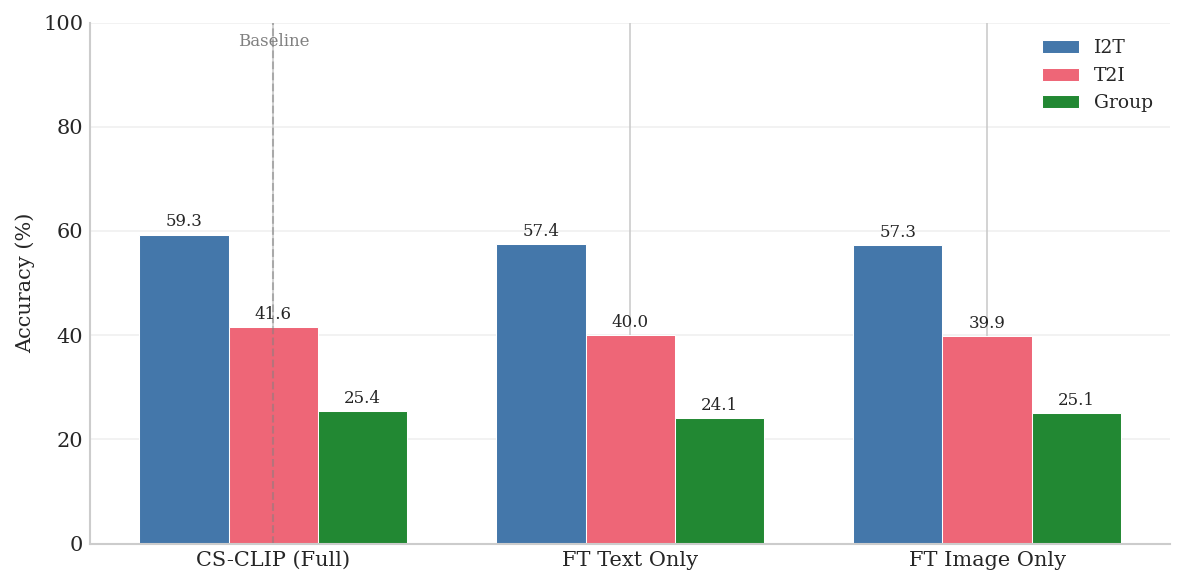

Saved: ../paper_figures/ablation_finetuning_metrics.pdf


In [ ]:
# =============================================================================
# VISUALIZATION: GROUPED BAR CHART (All Metrics)
# =============================================================================

fig, ax = plot_ablation_bars(
    summary_df,
    ABLATION_MODELS,
    title='Fine-tuning Strategy Ablation',
    save_path='../paper_figures/ablation_finetuning_bars.pdf'
)

In [ ]:
# =============================================================================
# COMPUTE DELTAS FROM BASELINE
# =============================================================================

deltas_df = compute_deltas(summary_df, ABLATION_MODELS)

print("\n" + "="*60)
print("DELTA FROM BASELINE (percentage points)")
print("="*60)
display(deltas_df.round(2).style.background_gradient(cmap='RdYlGn', axis=None))

Baseline model: CS-CLIP (Full)

DELTA FROM BASELINE (percentage points)


,VisMin,BLA/ap,SugarCrepe_PP/replace_attribute,SugarCrepe/swap_obj,ControlledImages/VG-Two,NegBench/msr_vtt_mcq_rephrased_llama,COLA/multi_objects,VALSE/existence,BLA/co,SugarCrepe_PP/replace_relation,VG_Attribution,COCO_Counterfactuals,NegBench/VOC2007_mcq_llama3.1_rephrased,SPEC_I2T/count,VALSE/plurals,BLA/rc,SugarCrepe/add_att,VG_Relation,Winoground,COCO_Order,SPEC_I2T/relative_spatial,VALSE/counting,SugarCrepe/add_obj,ControlledImages/A,NegBench/COCO_val_mcq_llama3.1_rephrased,Flickr30k_Order,SPEC_I2T/relative_size,VALSE/relations,ColorSwap,SugarCrepe/replace_att,ControlledImages/B,SPEC_I2T/absolute_size,VALSE/actions,SugarCrepe_PP/swap_object,SugarCrepe/replace_obj,ControlledImages/COCO-One,SPEC_I2T/absolute_spatial,VALSE/coreference,SugarCrepe_PP/swap_atribute,SugarCrepe/replace_rel,ControlledImages/COCO-Two,SPEC_I2T/existence,VALSE/noun phrases,SugarCrepe_PP/replace_object,SugarCrepe/swap_att,ControlledImages/VG-One,MMVP/Camera Perspective,MMVP/Color,MMVP/Orientation,MMVP/Presence,MMVP/Quantity,MMVP/Spatial,MMVP/State,MMVP/Structural Character,MMVP/Text,Average
Model,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
CS-CLIP (Full),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
FT Text Only,-2.210000,-0.330000,-0.250000,1.630000,-1.550000,3.100000,-0.480000,-6.930000,0.460000,-3.340000,-0.160000,-0.750000,-2.900000,-5.640000,-0.590000,-0.150000,0.720000,-2.410000,2.250000,-5.720000,-1.450000,-2.770000,-2.180000,-2.670000,0.610000,-5.480000,2.270000,-2.240000,-2.670000,0.760000,-1.230000,3.870000,-1.250000,-2.040000,-1.630000,-0.530000,1.870000,3.940000,-1.350000,-4.910000,-0.910000,-5.900000,-2.650000,-2.360000,-2.100000,-1.860000,6.670000,-13.330000,-6.670000,6.670000,0.000000,-33.330000,-6.670000,-6.670000,-13.330000,-2.310000
FT Image Only,-1.340000,-4.650000,-3.050000,-2.450000,0.000000,2.600000,-7.620000,-0.400000,0.920000,-2.770000,-1.690000,-1.140000,-1.030000,-2.200000,0.470000,-0.150000,-2.020000,-1.390000,-2.000000,-7.080000,0.250000,0.770000,-0.780000,1.210000,6.040000,-5.340000,0.000000,1.310000,1.000000,-0.380000,-3.680000,0.670000,-1.250000,-8.980000,-0.970000,-1.780000,0.090000,-0.740000,-4.200000,-0.780000,-2.050000,-8.500000,-0.320000,-2.060000,-2.400000,0.580000,6.670000,-6.670000,-6.670000,6.670000,0.000000,-13.330000,13.330000,0.000000,-13.330000,-1.500000


In [ ]:
# =============================================================================
# DATASET-WISE AND SUBSET-WISE TABLES (with ARO merging)
# =============================================================================

from ablation_utils import (
    load_all_models_per_dataset,
    load_all_models_per_subset,
    make_latex_dataset_table,
    get_datasets_and_subsets,
    display_all_tables,
    load_benchmark_config
)

# Load benchmark config for dataset merge rules (e.g., ARO)
bench_cfg = load_benchmark_config()

# Display all tables for the primary metric (I2T) with ARO merging
dataset_df, subset_df, datasets_subsets = display_all_tables(
    ABLATION_MODELS, PRIMARY_METRIC, CHECKPOINT_STEP, 
    show_latex=True, apply_merge=True, benchmark_config=bench_cfg
)